# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [3]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
336,-0.020045,-0.044642,0.085408,-0.036656,0.091996,0.089499,-0.061809,0.145012,0.080946,0.052770,306.0
29,0.067136,0.050680,-0.006206,0.063187,-0.042848,-0.095885,0.052322,-0.076395,0.059424,0.052770,283.0
312,-0.074533,-0.044642,-0.023451,-0.005670,-0.020832,-0.014153,0.015505,-0.039493,-0.038460,-0.030072,144.0
142,0.041708,0.050680,0.012117,0.039087,0.054845,0.044406,0.004460,-0.002592,0.045604,-0.001078,235.0
398,0.012648,-0.044642,0.015350,-0.033213,0.041086,0.032193,-0.002903,-0.002592,0.045067,-0.067351,242.0
277,-0.034575,-0.044642,-0.059019,0.001215,-0.053855,-0.078035,0.067048,-0.076395,-0.021395,0.015491,64.0
63,-0.034575,-0.044642,-0.037463,-0.060756,0.020446,0.043466,-0.013948,-0.002592,-0.030748,-0.071494,128.0
30,-0.060003,-0.044642,0.044451,-0.019442,-0.009825,-0.007577,0.022869,-0.039493,-0.027129,-0.009362,129.0
393,-0.074533,-0.044642,-0.046085,-0.043542,-0.029088,-0.023234,0.015505,-0.039493,-0.039809,-0.021788,69.0
190,0.009016,-0.044642,-0.012673,0.028758,-0.018080,-0.005072,-0.047082,0.034309,0.023371,-0.005220,292.0


In [4]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [5]:
data.isnull().sum()

age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64

### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [24]:
df = data.copy()
imputer = SimpleImputer(strategy="mean")

df[["bmi"]] = imputer.fit_transform(data[["bmi"]])


In [26]:
df.isnull().sum()

age        0
sex        0
bmi        0
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64

### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [27]:
df[['bmi', 'bp']] = imputer.fit_transform(data[['bmi', 'bp']])

In [28]:
knn_imputer = KNNImputer(n_neighbors=5)

df_knn = df.copy()
df_knn[['bmi', 'bp']] = knn_imputer.fit_transform(df[['bmi', 'bp']])

In [29]:
df[['bmi','bp']].isna().sum(), df[['bmi','bp']].isna().sum(), df_knn[['bmi','bp']].isna().sum()

(bmi    0
 bp     0
 dtype: int64,
 bmi    0
 bp     0
 dtype: int64,
 bmi    0
 bp     0
 dtype: int64)

In [30]:
df[['bmi','bp']].describe()
df_knn[['bmi','bp']].describe()

,bmi,bp
count,442.000000,442.000000
mean,-0.000205,0.000465
std,0.044583,0.045583
min,-0.089197,-0.112399
25%,-0.030996,-0.033213
50%,-0.000817,0.000465
75%,0.024781,0.028758
max,0.160855,0.132044


### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

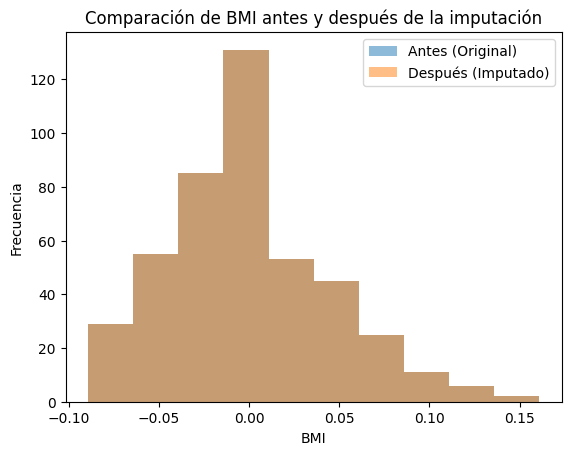

In [34]:
bmi_original = data['bmi']
bmi_imputado = df['bmi']   # o df_knn si quieres usar KNN

plt.figure()

plt.hist(bmi_original, alpha=0.5, label='Antes (Original)')
plt.hist(bmi_imputado, alpha=0.5, label='Después (Imputado)')

plt.xlabel('BMI')
plt.ylabel('Frecuencia')
plt.title('Comparación de BMI antes y después de la imputación')
plt.legend()

plt.show()